In [3]:
# import dependencies
import numpy as np
import pandas as pd
from floodlight.io.dfl import read_position_data_xml, read_event_data_xml, read_teamsheets_from_mat_info_xml
from data_import import load_event_data, load_position_data
import os
import matplotlib.pyplot as plt
path = "/Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/"

### Importing the data

I import the event data for one of the seven matches (i.e. match JO3WN1 - Vfl Bochum 1848 vs Bayer 04 Leverkusen).

In [4]:
# reading position data
position = read_position_data_xml(os.path.join(path, "DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml"),
                                  os.path.join(path, "DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WN1.xml"))

# reading event data
event = read_event_data_xml(os.path.join(path, "DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WN1.xml"),
                            os.path.join(path, "DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WN1.xml"))

It takes approximately 15 seconds to import all the data, therefore importing all 7 matches data will take approximately 2 mins.

Based on the `floodlight` package documentation (https://floodlight.readthedocs.io/en/latest/index.html), the output `position` tuple consists of the following:

* `xy_objects` nested dictionary containing `XY` objects for each team and segment of the form `xy_objects[segment][team] = XY`
* `possession_objects` is a dictionary containing `Code` objects with possession information (home or away) for each segment of the form `possession_objects[segment] = Code`.
* `ballstatus_objects` is a dictionary containing `Code` objects with ballstatus information (dead or alive) for each segment of the form `ballstatus_objects[segment] = Code`.
* `teamsheets` is a dictionary containing Teamsheet objects for each team of the form `teamsheets[team] = Teamsheet`.
* `pitch` is a `Pitch` object corresponding to the data.

The `event` tuple consists of the following:
* `events_objects` is a nested dictionary containing `Events` objects for each team and segment of the form `events_objects[segment][team] = Events`.
* `teamsheets` is a dictionary containing Teamsheet objects for each team of the form `teamsheets[team] = Teamsheet`.
* `pitch` is a `Pitch` object corresponding to the data.

I now plot the first 2 minutes of play from the game, using the inbuilt plotting methods.

<Axes: title={'center': 'Home Team Trajectories'}>

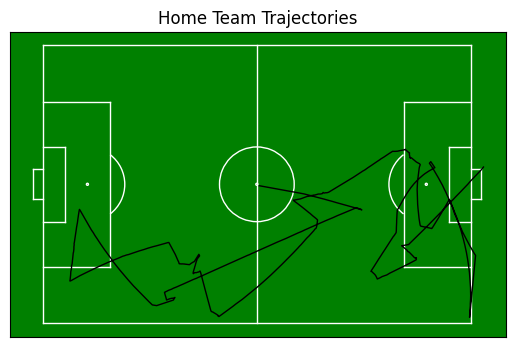

In [5]:
fig, ax = plt.subplots()
ax.set_title('Home Team Trajectories')
position[4].plot(ax=ax)
position[0]["firstHalf"]["Ball"].plot((0,3000), plot_type = 'trajectories', ax=ax)

I now want to explore the **event data** to understand the number of each event type in my dataset. To do this I use a function defined by Bassek et al. (https://github.com/spoho-datascience/idsse-data).

In [ ]:
# function to load the Event Data
def load_event_data(path):
    info_files = sorted([x for x in os.listdir(path) if "matchinformation" in x])
    event_files = sorted([x for x in os.listdir(path) if "events_raw" in x])
    all_events = pd.DataFrame()
    for events_file, info_file in zip(event_files, info_files):
        events, _, _ = read_event_data_xml(os.path.join(path, events_file), os.path.join(path, info_file))
        events_fullmatch = pd.DataFrame()
        for half in events:
            for team in events[half]:
                events_fullmatch = pd.concat([events_fullmatch, events[half][team].events])
        all_events = pd.concat([all_events, events_fullmatch], )
    return all_events

# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [33]:
# import event data
event_data = load_event_data(path)

# number of passes, crosses, tackles
event_list = ["Play_Pass", "TacklingGame", "Play_Cross"]
print(event_data[event_data["eID"].isin(event_list)].eID.value_counts())
print("\n")
# number of successful vs unsuccessful passes
passes = event_data[event_data.eID == "Play_Pass"].reset_index()
passes = pd.concat([passes, pd.json_normalize(passes.qualifier)], axis=1)
print(passes["Evaluation"].value_counts())


eID
Play_Pass       5241
TacklingGame    1412
Play_Cross       140
Name: count, dtype: int64


Evaluation
successfullyCompleted    4189
unsuccessful             1032
successful                 20
Name: count, dtype: int64


In [ ]:
# obtain the trajectories prior to an attempted pass

# Load Position Data
def load_position_data(path):
    info_files = [x for x in os.listdir(path) if "matchinformation" in x]
    position_files = [x for x in os.listdir(path) if "positions_raw" in x]
    for position_file, info_file in zip(position_files, info_files):
        positions, _, _, _, _ = read_position_data_xml(os.path.join(path, position_file), os.path.join(path, info_file))
    return positions